In [23]:
import torch
from pathlib import Path
from splice import _LocWrapper  # needed for unpickling the saved SPLICE model
from paths import load_paths

In [24]:
MODEL_NAME = "satclip_geospatial_all"   # keys: geoclip_geoyfcc, geoclip_geospatial_all, satclip_geospatial, satclip_geospatial_all, satclip_open_clip_vit_h_n500000
LOC_ENCODER = "satclip"

spec = load_paths()["splice"][MODEL_NAME]
device = "cuda:0"
splice_model = torch.load(spec["model"], map_location=device, weights_only=False)
concepts = torch.load(spec["concepts"], map_location=device, weights_only=False)

In [25]:
print(spec)

{'model': '/home/libe2152/projects/explainable-earth-embeddings/splice_results/txt-open_clip_vit_h__loc-satclip__tproj-linear__lproj-none__tft-lora__lft-only_proj__lora_r-8__loss-clip_symmetric__lr-0.0001__h-4bb7c457/concept_dictionary_n500000/splice_model.pt', 'concepts': '/home/libe2152/projects/explainable-earth-embeddings/splice_results/txt-open_clip_vit_h__loc-satclip__tproj-linear__lproj-none__tft-lora__lft-only_proj__lora_r-8__loss-clip_symmetric__lr-0.0001__h-4bb7c457/concept_dictionary_n500000/concepts.pt'}


In [26]:
out_path = f"figures/splice_decomposition/{MODEL_NAME}.png"

In [27]:
out_path = Path(out_path)
out_path.parent.mkdir(parents=True, exist_ok=True)

In [28]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

In [29]:
import torch.nn.functional as F
import pandas as pd
from tqdm import tqdm

df = pd.read_csv("~/data/s2-100k/index.csv")
subset_size = 1000
df = df.sample(subset_size, random_state=0).reset_index(drop=True)
latlons = torch.tensor(df[["lat", "lon"]].values, dtype=torch.float32).to(device)
splice_model.solver = "admm"

batch_size = 256
all_orig, all_weights, all_recon = [], [], []

with torch.no_grad():
    for i in tqdm(range(0, len(latlons), batch_size)):
        batch = latlons[i:i+batch_size]
        orig_b = F.normalize(splice_model.clip.encode_image(batch), dim=1)
        weights_b = splice_model.decompose(F.normalize(orig_b - splice_model.image_mean, dim=1))
        recon_b = splice_model.recompose_image(weights_b)
        all_orig.append(orig_b)
        all_weights.append(weights_b)
        all_recon.append(recon_b)

orig    = torch.cat(all_orig)
weights = torch.cat(all_weights)
recon   = torch.cat(all_recon)

mse      = F.mse_loss(recon, orig).item()
cos_sim  = (recon * orig).sum(dim=1).mean().item()
ss_res   = ((orig - recon) ** 2).sum()
ss_tot   = ((orig - orig.mean(0)) ** 2).sum()
r2       = (1 - ss_res / ss_tot).item()
l0_mean  = (weights > 0).float().sum(dim=1).mean().item()

print(f"MSE:              {mse:.4f}")
print(f"R²:               {r2:.4f}")
print(f"Cosine similarity:{cos_sim:.4f}")
print(f"Mean active concepts (L0): {l0_mean:.1f} / {weights.shape[1]}")

100%|██████████| 4/4 [00:03<00:00,  1.07it/s]

MSE:              0.0021
R²:               0.4607
Cosine similarity:0.7334
Mean active concepts (L0): 69.7 / 1021


In [30]:
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 24,
    "axes.linewidth": 0.6,
    "xtick.major.width": 0.6,
    "ytick.major.width": 0.6,
    "xtick.major.size": 3,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

In [31]:
locations = {
    # --- Urban / tourism anchor ---
    "Paris\n(Urban)":        ((48.8584,   2.2945), "#3a86ff"),

    # --- Desert contrast ---
    "Dubai\n(Desert)":           ((25.1972,  55.2744), "#7209b7"),
    "Sahara\n(Desert)":        ((22.2348,   7.9586), "#e76f51"),

    # --- Tropical contrast ---
    "Bali\n(Tropics)":        ((-8.4095, 115.1889), "#2ec4b6"),
    "Congo\n(Rainforest)":     ((0.7893,  23.6560), "#1b9e77"),

    # --- Forest / climate ---
    "Siberia\n(Taiga)":               ((61.5240, 105.3188), "#588157"),

    # --- Cold extreme ---
    # "Greenland\n(Ice)":         ((72.0000, -40.0000), "#90e0ef"),

    # --- Agriculture (strong signal) ---
    "Midwest US\n(Cropland)":         ((41.8780, -93.0977), "#e9c46a"),
}

In [32]:
top_k = 7

In [33]:
all_vals = []
for name, ((lat, lon), color) in locations.items():
    latlon = torch.tensor([[lat, lon]], dtype=torch.float32, device=device)
    with torch.no_grad():
        w, _ = splice_model.encode_image(latlon)
    pairs = sorted(zip(concepts, w[0].tolist()), key=lambda x: -x[1])
    pairs = [(c, v) for c, v in pairs if v > 0][:top_k]
    all_vals.extend([v for _, v in pairs])
xmax = max(all_vals) * 1.12

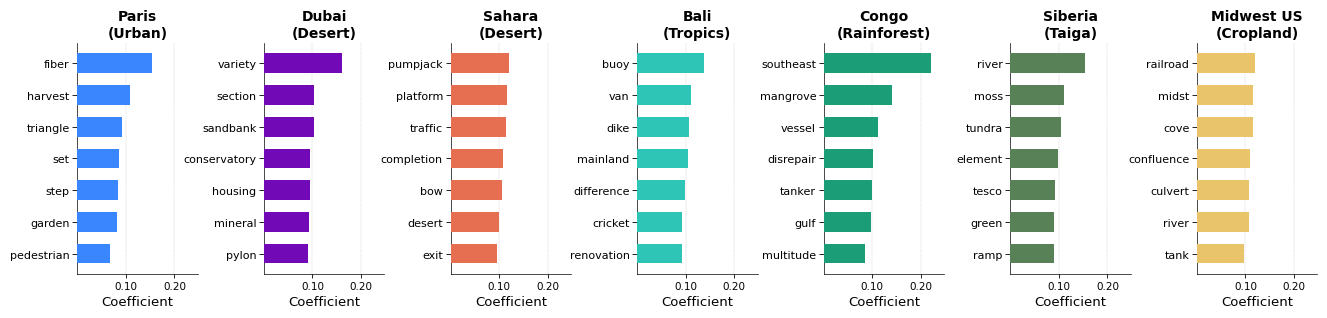

In [34]:
fig, axes = plt.subplots(1, len(locations), figsize=(16.0, 3.0),
                          gridspec_kw={"wspace": 0.55})

i=0
for ax, (name, ((lat, lon), color)) in zip(axes, locations.items()):
    latlon = torch.tensor([[lat, lon]], dtype=torch.float32, device=device)
    with torch.no_grad():
        w, _ = splice_model.encode_image(latlon)
    pairs = sorted(zip(concepts, w[0].tolist()), key=lambda x: -x[1])
    pairs = [(c, v) for c, v in pairs if v > 0][:top_k]
    if not pairs:
        continue
    labels, vals = zip(*pairs)
    y = np.arange(len(vals))

    ax.barh(y, vals, height=0.62, color=color, edgecolor="none", zorder=3)
    ax.set_yticks(y)
    ax.set_yticklabels(labels, fontsize=8)
    ax.invert_yaxis()
    ax.set_xlim(0, xmax)
    ax.set_xlabel("Coefficient", fontsize=9.5, labelpad=3)
    ax.set_title(name, fontsize=10, fontweight="bold", pad=4, linespacing=1.3)
    ax.xaxis.set_major_locator(mticker.MaxNLocator(3, prune="both"))
    ax.xaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f"))
    ax.tick_params(axis="x", labelsize=7.5, pad=2)
    ax.tick_params(axis="y", pad=2)
    ax.spines[["top", "right"]].set_visible(False)
    ax.spines[["left", "bottom"]].set_linewidth(0.5)
    ax.grid(axis="x", linewidth=0.35, linestyle="--", color="#cccccc", zorder=0)
    ax.set_axisbelow(True)

    # if i == 0:
    #     ax.text(
    #         0.02, 1.01, "(a)",
    #         transform=ax.transAxes,
    #         fontsize=8,
    #         va="top",
    #         ha="left"
    #     )
    # i+= 1

#plt.title(f"{LOC_ENCODER} SPLICE Decomposition", fontsize=9, fontweight="bold", pad=12)
plt.savefig(out_path, bbox_inches="tight", dpi=300)
plt.show()